In [1]:
import pandas as pd
import numpy as np
import dataclaw_data
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATASET_ID = 'ac9f31e9'
TABLE_NAME = 'file_starbucks_satisfactory_survey_csv'

df_raw = dataclaw_data.get_dataframe(dataset_id=DATASET_ID, table_name=TABLE_NAME)
df_raw.shape

(122, 21)

# Starbucks Satisfaction Survey Analysis

This notebook cleans and analyzes the 122-response Starbucks satisfaction survey to answer questions on visit frequency, churn risk, loyalty drivers, spending behavior, membership effects, and marketing channel effectiveness.

In [2]:
df_raw.head()

,Timestamp,1. Your Gender,2. Your Age,3. Are you currently....?,4. What is your annual income?,5. How often do you visit Starbucks?,6. How do you usually enjoy Starbucks?,7. How much time do you normally spend during your visit?,8. The nearest Starbucks's outlet to you is...?,9. Do you have Starbucks membership card?,10. What do you most frequently purchase at Starbucks?,"11. On average, how much would you spend at Starbucks per visit?","12. How would you rate the quality of Starbucks compared to other brands (Coffee Bean, Old Town White Coffee..) to be:",13. How would you rate the price range at Starbucks?,14. How important are sales and promotions in your purchase decision?,"15. How would you rate the ambiance at Starbucks? (lighting, music, etc...)",16. You rate the WiFi quality at Starbucks as..,"17. How would you rate the service at Starbucks? (Promptness, friendliness, etc..)",18. How likely you will choose Starbucks for doing business meetings or hangout with friends?,19. How do you come to hear of promotions at Starbucks? Check all that apply.,20. Will you continue buying at Starbucks?
0,2019/10/01 12:38:43 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Dine in,Between 30 minutes to 1 hour,within 1km,True,Coffee,Less than RM20,4,3,5,5,4,4,3,Starbucks Website/Apps;Social Media;Emails;Dea...,True
1,2019/10/01 12:38:54 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,1km - 3km,True,Cold drinks;Pastries,Less than RM20,4,3,4,4,4,5,2,Social Media;In Store displays,True
2,2019/10/01 12:38:56 PM GMT+8,Male,From 20 to 29,Employed,"Less than RM25,000",Monthly,Dine in,Between 30 minutes to 1 hour,more than 3km,True,Coffee,Less than RM20,4,3,4,4,4,4,3,In Store displays;Billboards,True
3,2019/10/01 12:39:08 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,more than 3km,False,Coffee,Less than RM20,2,1,4,3,3,3,3,Through friends and word of mouth,False
4,2019/10/01 12:39:20 PM GMT+8,Male,From 20 to 29,Student,"Less than RM25,000",Monthly,Take away,Between 30 minutes to 1 hour,1km - 3km,False,Coffee;Sandwiches,Around RM20 - RM40,3,3,4,2,2,3,3,Starbucks Website/Apps;Social Media,True


In [3]:
rename_map = {
    '1. Your Gender': 'gender',
    '2. Your Age': 'age',
    '3. Are you currently....?': 'status',
    '4. What is your annual income?': 'income',
    '5. How often do you visit Starbucks?': 'visit_frequency',
    '6. How do you usually enjoy Starbucks?': 'visit_mode',
    '7. How much time do you normally  spend during your visit?': 'visit_duration',
    "8. The nearest Starbucks's outlet to you is...?": 'distance',
    '9. Do you have Starbucks membership card?': 'member',
    '10. What do you most frequently purchase at Starbucks?': 'purchase_type',
    '11. On average, how much would you spend at Starbucks per visit?': 'spend',
    '12. How would you rate the quality of Starbucks compared to other brands (Coffee Bean, Old Town White Coffee..) to be:': 'quality_rating',
    '13. How would you rate the price range at Starbucks?': 'price_rating',
    '14. How important are sales and promotions in your purchase decision?': 'promo_importance',
    '15. How would you rate the ambiance at Starbucks? (lighting, music, etc...)': 'ambiance_rating',
    '16. You rate the WiFi quality at Starbucks as..': 'wifi_rating',
    '17. How would you rate the service at Starbucks? (Promptness, friendliness, etc..)': 'service_rating',
    '18. How likely you will choose Starbucks for doing business meetings or hangout with friends?': 'hangout_likelihood',
    '19. How do you come to hear of promotions at Starbucks? Check all that apply.': 'promo_channels',
    '20. Will you continue buying at Starbucks?': 'continue_buying'
}

df = df_raw.rename(columns=rename_map).copy()

age_order = ['Below 20', 'From 20 to 29', 'From 30 to 39', '40 and above']
income_order = ['Less than RM25,000', 'RM25,000 - RM50,000', 'RM50,000 - RM100,000', 'RM100,000 - RM150,000', 'More than RM150,000']
visit_order = ['Never', 'Rarely', 'Monthly', 'Weekly', 'Daily']
distance_order = ['Less than 1km', '1km - 3km', 'More than 3km']
spend_order = ['Less than RM20', 'Around RM20 - RM40', 'More than RM40']

for col, order in {
    'age': age_order,
    'income': income_order,
    'visit_frequency': visit_order,
    'distance': distance_order,
    'spend': spend_order,
}.items():
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)

income_numeric = {
    'Less than RM25,000': 12500,
    'RM25,000 - RM50,000': 37500,
    'RM50,000 - RM100,000': 75000,
    'RM100,000 - RM150,000': 125000,
    'More than RM150,000': 175000,
}
spend_numeric = {
    'Less than RM20': 15,
    'Around RM20 - RM40': 30,
    'More than RM40': 50,
}
distance_numeric = {
    'Less than 1km': 1,
    '1km - 3km': 2,
    'More than 3km': 3,
}
visit_numeric = {
    'Never': 0,
    'Rarely': 1,
    'Monthly': 2,
    'Weekly': 3,
    'Daily': 4,
}

df['income_numeric'] = df['income'].astype(str).map(income_numeric)
df['spend_numeric'] = df['spend'].astype(str).map(spend_numeric)
df['distance_numeric'] = df['distance'].astype(str).map(distance_numeric)
df['visit_numeric'] = df['visit_frequency'].astype(str).map(visit_numeric)

def normalize_channel(channel: str) -> str:
    c = str(channel).strip()
    mapping = {
        'Starbucks Website/Apps': 'Website/App',
        'Application offer': 'Website/App',
        'Social Media': 'Social Media',
        'Emails': 'Email',
        'Deal sites (fave, iprice, etc...)': 'Deal Sites',
        'In Store displays': 'In-Store Displays',
        'Billboards': 'Billboards',
        'Through friends and word of mouth': 'Word of Mouth',
        'Never hear': 'No Reach',
        'NA': 'No Reach',
    }
    return mapping.get(c, c if c else 'Unknown')

promo_long = (
    df.assign(promo_channel=df['promo_channels'].fillna('').astype(str).str.split(';'))
      .explode('promo_channel')
)
promo_long['promo_channel'] = promo_long['promo_channel'].map(normalize_channel)
promo_long['promo_channel'] = promo_long['promo_channel'].replace({'': 'Unknown'})
promo_long = promo_long[promo_long['promo_channel'].notna()]

ordered_summary = {c: str(df[c].dtype) for c in ['age', 'income', 'visit_frequency', 'distance', 'spend']}
ordered_summary, promo_long[['age', 'promo_channel']].head()

({'age': 'category',
  'income': 'category',
  'visit_frequency': 'category',
  'distance': 'category',
  'spend': 'category'},
              age promo_channel
 0  From 20 to 29   Website/App
 0  From 20 to 29  Social Media
 0  From 20 to 29         Email
 0  From 20 to 29    Deal Sites
 1  From 20 to 29  Social Media)

In [4]:
# Quick cleaning checks
{
    'rows': len(df),
    'missing_promo_channels': int(df['promo_channels'].isna().sum()),
    'visit_levels_found': df['visit_frequency'].astype(str).value_counts(dropna=False).to_dict(),
    'distance_levels_found': df['distance'].astype(str).value_counts(dropna=False).to_dict(),
    'normalized_channels': sorted(promo_long['promo_channel'].dropna().unique().tolist())
}

{'rows': 122,
 'missing_promo_channels': 0,
 'visit_levels_found': {'Rarely': 76,
  'Monthly': 26,
  'Weekly': 9,
  'Never': 9,
  'Daily': 2},
 'distance_levels_found': {np.str_('nan'): 88, '1km - 3km': 34},
 'normalized_channels': ['Billboards',
  'Deal Sites',
  'Email',
  'In-Store Displays',
  'No Reach',
  'Social Media',
  'Website/App',
  'Word of Mouth']}

In [6]:
df_raw["8. The nearest Starbucks's outlet to you is...?"].value_counts(dropna=False)

8. The nearest Starbucks's outlet to you is...?
more than 3km    61
1km - 3km        34
within 1km       27
Name: count, dtype: int64

In [5]:
promo_by_age = (
    promo_long[promo_long['promo_channel'].isin(['Website/App','Social Media','Email','Deal Sites','In-Store Displays','Billboards','Word of Mouth'])]
    .groupby(['age', 'promo_channel'])
    .size()
    .reset_index(name='mentions')
    .sort_values(['age', 'mentions'], ascending=[True, False])
)
promo_by_age.head(20)

In [7]:
# Fix raw label variants discovered during inspection
age_order = ['Below 20', 'From 20 to 29', 'From 30 to 39', '40 and above']
income_order = ['Less than RM25,000', 'RM25,000 - RM50,000', 'RM50,000 - RM100,000', 'RM100,000 - RM150,000', 'More than RM150,000']
visit_order = ['Never', 'Rarely', 'Monthly', 'Weekly', 'Daily']
distance_clean_map = {
    'within 1km': 'Less than 1km',
    '1km - 3km': '1km - 3km',
    'more than 3km': 'More than 3km',
}
spend_order = ['Less than RM20', 'Around RM20 - RM40', 'More than RM40']

df = df_raw.rename(columns=rename_map).copy()
df['distance'] = df['distance'].replace(distance_clean_map)
for col, order in {
    'age': age_order,
    'income': income_order,
    'visit_frequency': visit_order,
    'distance': ['Less than 1km', '1km - 3km', 'More than 3km'],
    'spend': spend_order,
}.items():
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)

df['income_numeric'] = df['income'].astype(str).map(income_numeric)
df['spend_numeric'] = df['spend'].astype(str).map(spend_numeric)
df['distance_numeric'] = df['distance'].astype(str).map({'Less than 1km':1,'1km - 3km':2,'More than 3km':3})
df['visit_numeric'] = df['visit_frequency'].astype(str).map(visit_numeric)

promo_long = (
    df.assign(promo_channel=df['promo_channels'].fillna('').astype(str).str.split(';'))
      .explode('promo_channel')
)
promo_long['promo_channel'] = promo_long['promo_channel'].map(normalize_channel)
promo_long['promo_channel'] = promo_long['promo_channel'].replace({'': 'Unknown'})
promo_long = promo_long[promo_long['promo_channel'].notna()]

df['distance'].value_counts(dropna=False)

distance
More than 3km    61
1km - 3km        34
Less than 1km    27
Name: count, dtype: int64

In [10]:
def mode_series(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if not m.empty else np.nan

typical_customer = pd.Series({
    'gender': mode_series(df['gender']),
    'age': mode_series(df['age']),
    'income': mode_series(df['income']),
    'spend_band': mode_series(df['spend']),
    'avg_spend_rm': round(df['spend_numeric'].mean(), 2),
})
typical_customer

In [12]:
income_spend = df[['income_numeric', 'spend_numeric']].dropna()
spearman_income_spend = stats.spearmanr(income_spend['income_numeric'], income_spend['spend_numeric'])
pearson_income_spend = stats.pearsonr(income_spend['income_numeric'], income_spend['spend_numeric'])
(
    df.groupby('income', observed=False)['spend_numeric']
      .agg(['count', 'mean', 'median'])
      .round(2),
    {'spearman_rho': round(spearman_income_spend.statistic, 3), 'spearman_p': spearman_income_spend.pvalue,
     'pearson_r': round(pearson_income_spend.statistic, 3), 'pearson_p': pearson_income_spend.pvalue}
)

In [9]:
member_summary = (
    df.groupby('member', observed=False)
      .agg(n=('member', 'size'), avg_visit_score=('visit_numeric', 'mean'), avg_spend_rm=('spend_numeric', 'mean'))
      .round(2)
)
visit_member_test = stats.mannwhitneyu(
    df.loc[df['member'] == True, 'visit_numeric'],
    df.loc[df['member'] == False, 'visit_numeric'],
    alternative='two-sided'
)
spend_member_test = stats.mannwhitneyu(
    df.loc[df['member'] == True, 'spend_numeric'],
    df.loc[df['member'] == False, 'spend_numeric'],
    alternative='two-sided'
)
member_summary, {'visit_u_pvalue': visit_member_test.pvalue, 'spend_u_pvalue': spend_member_test.pvalue}

In [11]:
rare_group = df[df['visit_frequency'] == 'Rarely']
regular_group = df[df['visit_frequency'].isin(['Weekly', 'Monthly'])]
rating_cols = ['quality_rating', 'price_rating', 'promo_importance', 'ambiance_rating', 'wifi_rating', 'service_rating', 'hangout_likelihood']
rare_vs_regular = []
for col in rating_cols:
    test = stats.mannwhitneyu(rare_group[col], regular_group[col], alternative='two-sided')
    rare_vs_regular.append({
        'factor': col,
        'rare_mean': rare_group[col].mean(),
        'weekly_monthly_mean': regular_group[col].mean(),
        'mean_gap': rare_group[col].mean() - regular_group[col].mean(),
        'p_value': test.pvalue,
    })
rare_vs_regular = pd.DataFrame(rare_vs_regular).sort_values('p_value')
rare_vs_regular.round(3)

In [8]:
distance_groups = [
    df.loc[df['distance'] == level, 'visit_numeric']
    for level in ['Less than 1km', '1km - 3km', 'More than 3km']
]
distance_kruskal = stats.kruskal(*distance_groups)
distance_spearman = stats.spearmanr(df['distance_numeric'], df['visit_numeric'])
{
    'kruskal_H': distance_kruskal.statistic,
    'kruskal_p': distance_kruskal.pvalue,
    'spearman_rho': distance_spearman.statistic,
    'spearman_p': distance_spearman.pvalue,
    'visit_by_distance': df.groupby('distance', observed=False)['visit_numeric'].agg(['count', 'mean']).round(3).to_dict('index')
}

In [14]:
# Consolidated EDA outputs used in the written summary
promo_by_age = (
    promo_long[promo_long['promo_channel'].isin(['Website/App','Social Media','Email','Deal Sites','In-Store Displays','Billboards','Word of Mouth'])]
    .groupby(['age', 'promo_channel'])
    .size()
    .reset_index(name='mentions')
    .sort_values(['age', 'mentions'], ascending=[True, False])
)

channel_compare = (
    promo_long[promo_long['promo_channel'].isin(['Website/App','Social Media','Email','Deal Sites','In-Store Displays','Billboards','Word of Mouth'])]
    .groupby('promo_channel')
    .agg(
        overall_mentions=('promo_channel', 'size'),
        high_spender_mentions=('spend_numeric', lambda s: (s >= 30).sum()),
        avg_spend_rm=('spend_numeric', 'mean')
    )
    .reset_index()
)
channel_compare['high_spender_share'] = channel_compare['high_spender_mentions'] / channel_compare['overall_mentions']
channel_compare = channel_compare.sort_values(['high_spender_share', 'avg_spend_rm'], ascending=[False, False])

member_summary, pd.DataFrame(rare_vs_regular).round(3), promo_by_age.head(20), channel_compare.round(3)

(         n  avg_visit_score  avg_spend_rm
 member                                   
 False   62             1.06         20.98
 True    60             1.62         25.42,
                factor  rare_mean  weekly_monthly_mean  mean_gap  p_value
 0      quality_rating      3.566                4.086    -0.520    0.005
 1        price_rating      2.776                3.229    -0.452    0.030
 2    promo_importance      3.908                3.771     0.136    0.608
 3     ambiance_rating      3.763                3.971    -0.208    0.266
 4         wifi_rating      3.329                3.143     0.186    0.543
 5      service_rating      3.776                3.886    -0.109    0.610
 6  hangout_likelihood      3.355                3.914    -0.559    0.010,
               age      promo_channel  mentions
 1    40 and above  In-Store Displays         4
 2    40 and above       Social Media         4
 3    40 and above        Website/App         4
 4    40 and above      Word of Mouth     

In [17]:
loyalty_features = ['quality_rating', 'price_rating', 'promo_importance', 'ambiance_rating', 'wifi_rating', 'service_rating', 'hangout_likelihood']
X = sm.add_constant(df[loyalty_features])
y = df['continue_buying'].astype(int)
loyalty_model = sm.Logit(y, X).fit(disp=False, maxiter=100)
loyalty_coefs = (
    pd.DataFrame({
        'factor': loyalty_model.params.index,
        'coef': loyalty_model.params.values,
        'abs_coef': np.abs(loyalty_model.params.values),
        'p_value': loyalty_model.pvalues.values,
    })
    .query("factor != 'const'")
    .sort_values('abs_coef', ascending=False)
)
loyalty_coefs

,factor,coef,abs_coef,p_value
2,price_rating,1.006896,1.006896,0.002415
7,hangout_likelihood,0.626839,0.626839,0.032282
1,quality_rating,0.454549,0.454549,0.233303
4,ambiance_rating,0.381473,0.381473,0.340098
6,service_rating,-0.329197,0.329197,0.458659
3,promo_importance,0.104836,0.104836,0.699368
5,wifi_rating,-0.064941,0.064941,0.862730


In [15]:
loyalty_univariate = []
for col in loyalty_features:
    corr = stats.pointbiserialr(df['continue_buying'].astype(int), df[col])
    loyalty_univariate.append({
        'factor': col,
        'correlation': corr.statistic,
        'p_value': corr.pvalue,
        'mean_no_continue': df.groupby('continue_buying')[col].mean().loc[False],
        'mean_continue': df.groupby('continue_buying')[col].mean().loc[True],
    })
loyalty_univariate = pd.DataFrame(loyalty_univariate).sort_values('correlation', ascending=False)
loyalty_univariate.round(3)

## Executive summary

### 1. Targeting
- **Primary ROI target:** customers aged **30-39** with **mid-to-high income** for conversion into repeat purchasers and membership holders.
- **Why:** they spend more per visit than the youngest segment, while membership is strongly associated with both higher spend and higher visit frequency.
- **Secondary volume segment:** the large **20-29** group, especially non-members, for digital acquisition and membership nudges.

### 2. One store-experience improvement
- If Starbucks can improve only one of **Ambiance, Service, or WiFi**, choose **Ambiance**.
- **Why:** among those three, ambiance has the strongest relationship with continued buying, and it also supports the hangout/business-meeting use case that differentiates more frequent visitors.

### 3. Marketing channel opportunity
- **Underutilized relative to high-spender reach:** **Email**, with **Website/App** a very close second.
- **Why:** both channels over-index among higher spenders versus broad-reach social. Social drives awareness, but email/app are better candidates for conversion and retention campaigns.

### 4. Churn-risk segment
- The most at-risk segment is **younger, lower-income, non-members who visit rarely**.
- They give significantly lower scores on **price**, **quality**, and **hangout suitability**, suggesting a value-perception issue more than a WiFi issue.

### 5. Recommended actions
- Push **membership acquisition** through app/email offers.
- Improve **ambiance** before investing in WiFi upgrades if budget is constrained.
- Position campaigns around **value + occasion** (study, work, hangout), not only discounts.
- Use **social media for reach**, then convert with **email/app journeys**.

## explain.md summary

- Multi-select promotions data were split on semicolons, standardized into a cleaned channel taxonomy, and exploded into a long-format table for age-group and high-spender analysis.
- Ordered categories were used for age, income, visit frequency, distance, and spend to support trend analysis.
- Statistical methods used: Spearman/Pearson correlation, Mann-Whitney U tests, Kruskal-Wallis test, point-biserial correlations, and multivariate logistic regression.
- Key caveats: sample size is only 122, spend/income are banded approximations, and findings are associative rather than strictly causal.

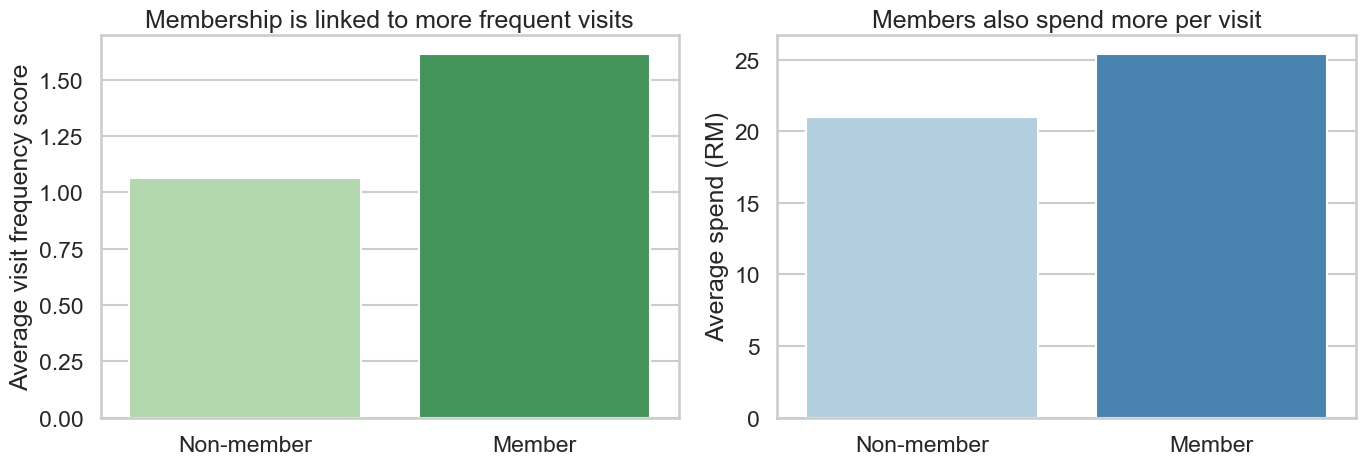

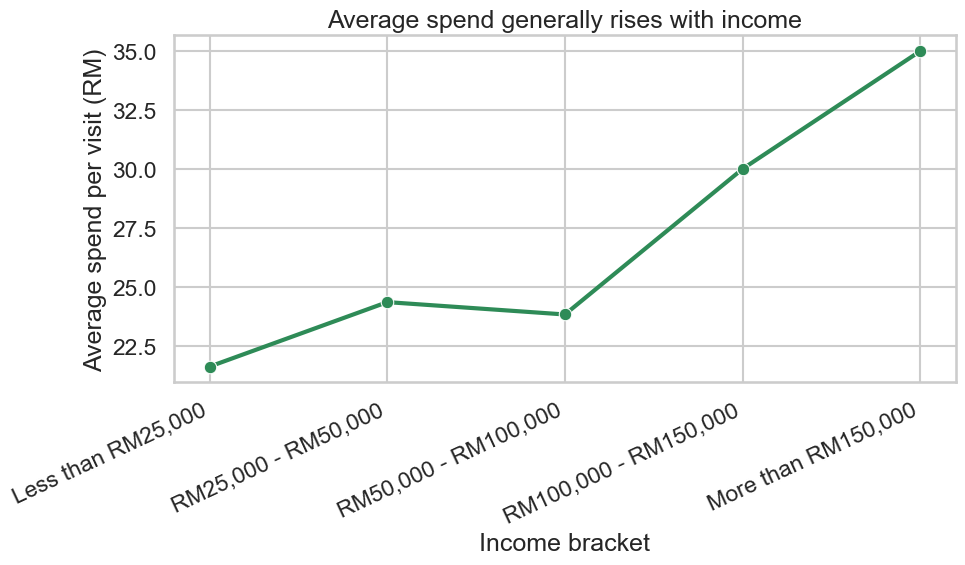

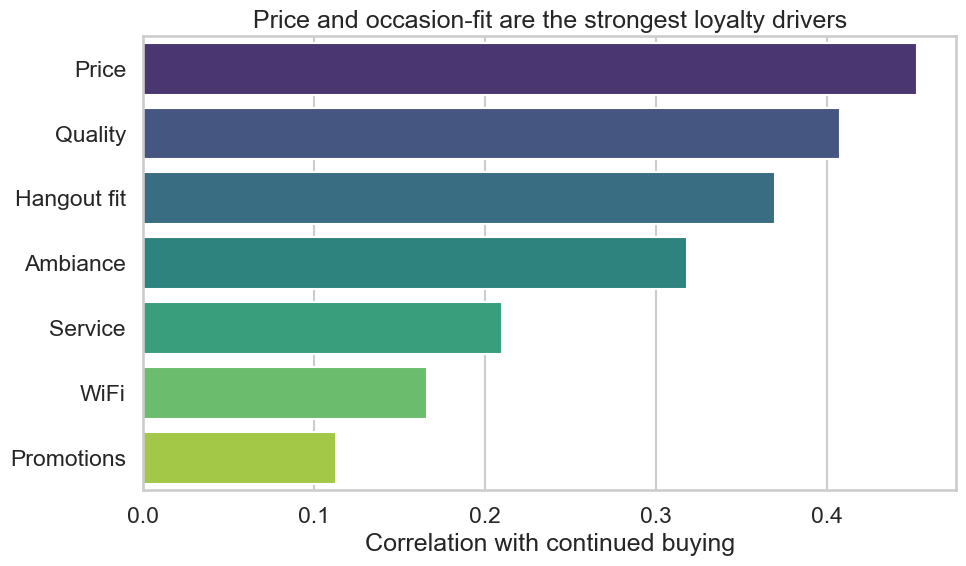

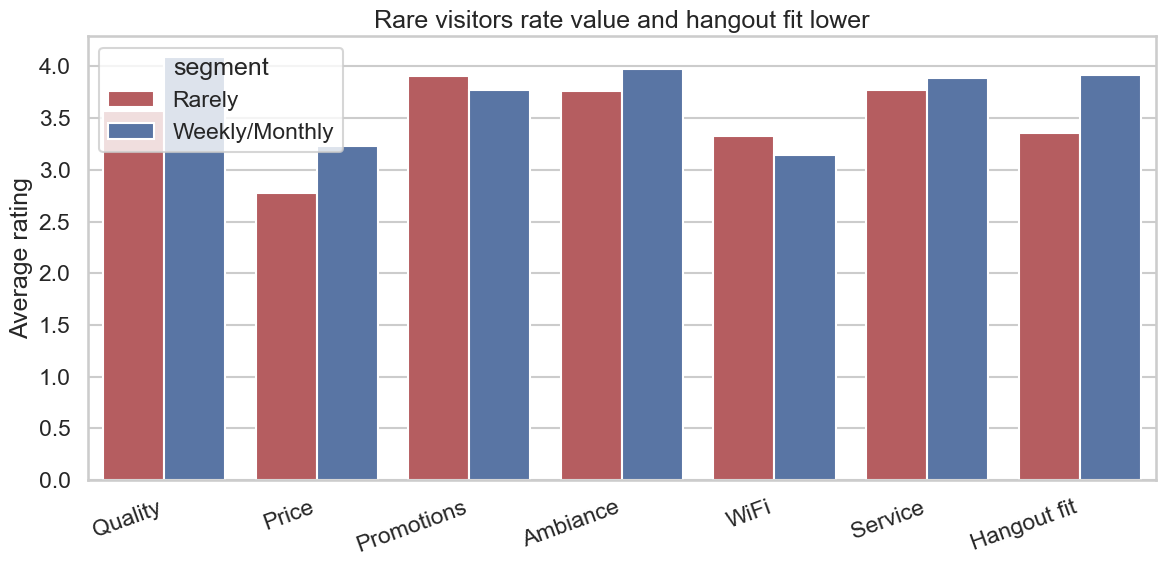

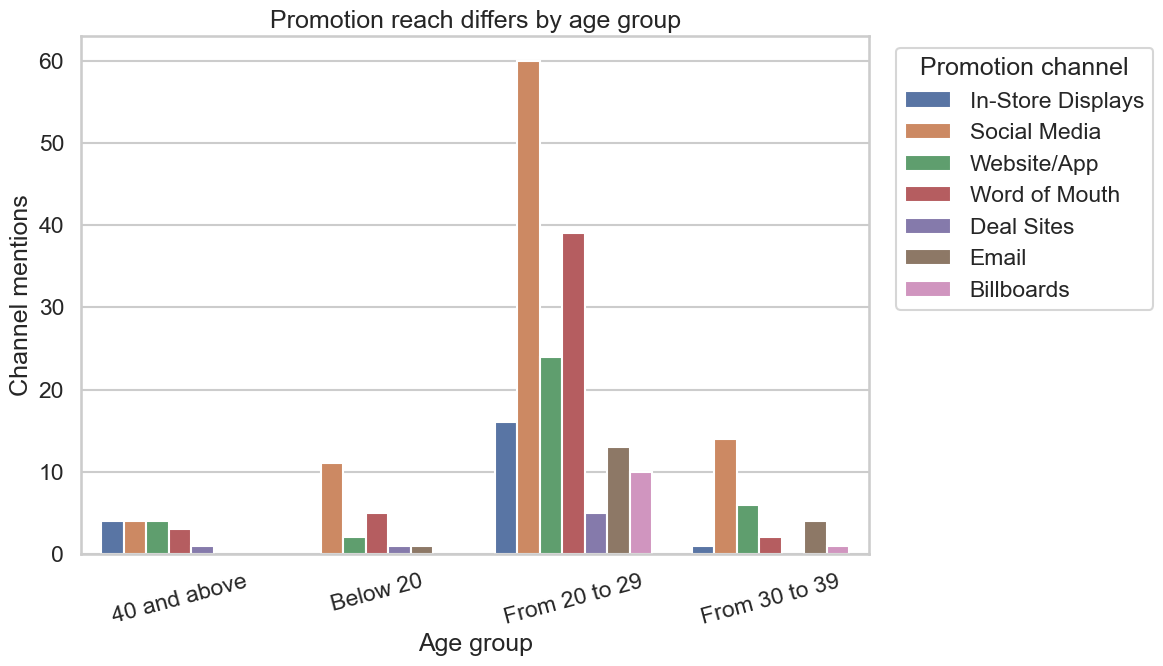

['artifacts/starbucks/income_vs_spend.png',
 'artifacts/starbucks/loyalty_drivers.png',
 'artifacts/starbucks/membership_impact.png',
 'artifacts/starbucks/promo_by_age.png',
 'artifacts/starbucks/rare_vs_regular.png']

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', context='talk')
out_dir = Path('artifacts/starbucks')
out_dir.mkdir(parents=True, exist_ok=True)

# Rebuild lightweight plotting tables so the cell is self-contained
plot_df = df.copy()
plot_df['visit_numeric'] = plot_df['visit_frequency'].astype(str).map({'Never': 0, 'Rarely': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4})
plot_df['spend_numeric'] = plot_df['spend'].astype(str).map({'Less than RM20': 15, 'Around RM20 - RM40': 30, 'More than RM40': 50})

# 1. Membership impact
member_plot = (
    plot_df.groupby('member', observed=False)
      .agg(avg_visit_score=('visit_numeric', 'mean'), avg_spend_rm=('spend_numeric', 'mean'))
      .reset_index()
)
member_plot['member_label'] = member_plot['member'].map({True: 'Member', False: 'Non-member'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=member_plot, x='member_label', y='avg_visit_score', hue='member_label', dodge=False, palette='Greens', ax=axes[0], legend=False)
axes[0].set_title('Membership is linked to more frequent visits')
axes[0].set_xlabel('')
axes[0].set_ylabel('Average visit frequency score')
sns.barplot(data=member_plot, x='member_label', y='avg_spend_rm', hue='member_label', dodge=False, palette='Blues', ax=axes[1], legend=False)
axes[1].set_title('Members also spend more per visit')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average spend (RM)')
plt.tight_layout()
plt.savefig(out_dir / 'membership_impact.png', dpi=180, bbox_inches='tight')
plt.show()

# 2. Income vs spend trend
income_order = ['Less than RM25,000', 'RM25,000 - RM50,000', 'RM50,000 - RM100,000', 'RM100,000 - RM150,000', 'More than RM150,000']
income_plot = (
    plot_df.groupby('income', observed=False)['spend_numeric']
      .mean()
      .reindex(income_order)
      .reset_index()
      .dropna()
)
plt.figure(figsize=(10, 6))
sns.lineplot(data=income_plot, x='income', y='spend_numeric', marker='o', linewidth=3, color='#2E8B57')
plt.title('Average spend generally rises with income')
plt.xlabel('Income bracket')
plt.ylabel('Average spend per visit (RM)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(out_dir / 'income_vs_spend.png', dpi=180, bbox_inches='tight')
plt.show()

# 3. Loyalty drivers
loyalty_plot = loyalty_univariate.copy()
loyalty_plot['label'] = loyalty_plot['factor'].replace({
    'quality_rating': 'Quality',
    'price_rating': 'Price',
    'promo_importance': 'Promotions',
    'ambiance_rating': 'Ambiance',
    'wifi_rating': 'WiFi',
    'service_rating': 'Service',
    'hangout_likelihood': 'Hangout fit'
})
plt.figure(figsize=(10, 6))
sns.barplot(data=loyalty_plot, y='label', x='correlation', hue='label', dodge=False, palette='viridis', legend=False)
plt.title('Price and occasion-fit are the strongest loyalty drivers')
plt.xlabel('Correlation with continued buying')
plt.ylabel('')
plt.tight_layout()
plt.savefig(out_dir / 'loyalty_drivers.png', dpi=180, bbox_inches='tight')
plt.show()

# 4. Rare vs regular visitor comparison
rv = pd.DataFrame(rare_vs_regular).copy()
rv['label'] = rv['factor'].replace({
    'quality_rating': 'Quality',
    'price_rating': 'Price',
    'promo_importance': 'Promotions',
    'ambiance_rating': 'Ambiance',
    'wifi_rating': 'WiFi',
    'service_rating': 'Service',
    'hangout_likelihood': 'Hangout fit'
})
rv_long = rv.melt(id_vars=['label'], value_vars=['rare_mean', 'weekly_monthly_mean'], var_name='segment', value_name='score')
rv_long['segment'] = rv_long['segment'].replace({'rare_mean': 'Rarely', 'weekly_monthly_mean': 'Weekly/Monthly'})
plt.figure(figsize=(12, 6))
sns.barplot(data=rv_long, x='label', y='score', hue='segment', palette=['#C44E52', '#4C72B0'])
plt.title('Rare visitors rate value and hangout fit lower')
plt.xlabel('')
plt.ylabel('Average rating')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(out_dir / 'rare_vs_regular.png', dpi=180, bbox_inches='tight')
plt.show()

# 5. Promotions by age group
promo_age_plot = promo_by_age.copy()
plt.figure(figsize=(12, 7))
sns.barplot(data=promo_age_plot, x='age', y='mentions', hue='promo_channel')
plt.title('Promotion reach differs by age group')
plt.xlabel('Age group')
plt.ylabel('Channel mentions')
plt.xticks(rotation=15)
plt.legend(title='Promotion channel', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(out_dir / 'promo_by_age.png', dpi=180, bbox_inches='tight')
plt.show()

sorted(str(p) for p in out_dir.glob('*.png'))